<center>

# **Maestría en Inteligencia Artificial Aplicada**

[![Institution](https://img.shields.io/badge/Instituto-Tecnológico%20de%20Monterrey-1F497D?style=for-the-badge&logo=graduation-cap)](https://tec.mx)
[![Course](https://img.shields.io/badge/Curso-Navegación%20autónoma-FF6B6B?style=for-the-badge&logo=eye)](https://tec.mx)![Activity](https://img.shields.io/badge/Actividad%203.1-Detección%20de%20Peatones%20con%20SVM-F9AB00?style=for-the-badge&logo=googlecolab)


</center>

### **Profesores**
- **Profesor Titular:** Dr. David Antonio Torres
- **Profesor Asistente:** Mtra. Yetnalezi Quintas Ruiz
---

## **Equipo 01**

<div style="display: flex; justify-content: center; margin: 20px 0;">
  <table style="border-collapse: collapse; font-family: Arial, sans-serif;">
    <thead>
      <tr style="border-bottom: 2px solid #333;">
        <th style="padding: 10px 40px; text-align: center;">Nombre</th>
        <th style="padding: 10px 40px; text-align: center;">Matrícula</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Luis Gabriel Lobato Barajas</td>
        <td style="padding: 8px 40px; text-align: center;">A01797069</td>
      </tr>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Ángel Eduardo Pérez Cruz</td>
        <td style="padding: 8px 40px; text-align: center;">A01797661</td>
      </tr>
      <tr style="border-bottom: 1px solid #ccc;">
        <td style="padding: 8px 40px; text-align: center;">Juan Carlos Pérez Nava</td>
        <td style="padding: 8px 40px; text-align: center;">A01795941</td>
      </tr>
      <tr>
        <td style="padding: 8px 40px; text-align: center;">Israel Sánchez Arenas</td>
        <td style="padding: 8px 40px; text-align: center;">A01797385</td>
      </tr>
    </tbody>
  </table>
</div>


### **Detalles de la Actividad**
- **Título:** Detección de Peatones con SVM
- **Fecha de entrega:** Mayo 26 2026
- **Modalidad:** Equipo

## **<font color="orange">Objetivo del Proyecto</font>**

Identificar la Máquina de Soporte Vectorial como una herramienta importante para la detección de peatones en vehículos autónomos.


## **<font color="orange">Desarrollo del pipeline de detección de peatones</font>**

Para el desarrollo del código se tomaron como base los ejemplos proporcionados en los
recursos de apoyo del curso (*apartado Recursos de Apoyo*), complementándolos
progresivamente para construir un pipeline más completo y adaptado a las necesidades
específicas del problema de detección de peatones.

### Decisiones de diseño

**Dataset y preprocesamiento**
Se utilizó el dataset público `marcelarosalesj/inria-person` disponible en HuggingFace,
que contiene imágenes etiquetadas de peatones y no peatones. Cada imagen se convirtió a
escala de grises y se redimensionó a **32×64 px**, estableciendo un tamaño estándar
uniforme para la extracción de descriptores. Adicionalmente se incorporaron imágenes
capturadas directamente desde el simulador Webots para mejorar la generalización del
modelo en el entorno de uso.

**Data augmentation**
Para ampliar el dataset de entrenamiento se implementó una función de augmentation
que aplica flip horizontal, rotación leve, variación de brillo y ruido gaussiano,
triplicando el número de muestras disponibles para el entrenamiento.

**Extracción de características**
Se implementó HOG (*Histogram of Oriented Gradients*) con celdas de 4×4 px,
bloques de 2×2 celdas y 9 orientaciones, produciendo un vector de 3,780 features
por imagen. Esta configuración fue seleccionada por ser la más documentada para
detección de peatones en la literatura de visión por computadora.

Se eligieron celdas de 4×4 px principalmente por dos razones. La primera es que las
imágenes son de resolución reducida, por lo que usar celdas más grandes haría perder
demasiado detalle en el descriptor (MathWorks, s.f.; Fiveable, 2026)..

La segunda es que el modelo corre en tiempo real dentro del simulador, y el tiempo de procesamiento
del SVM crece con el tamaño del vector de features, por lo que mantener un vector compacto ayuda a que el sistema responda con mayor fluidez, sacrificando lo menor posible la precisión.

**Normalización**
Se aplicó `StandardScaler` sobre los descriptores HOG antes del entrenamiento,
ajustado únicamente sobre el conjunto de entrenamiento para evitar *data leakage*.

**Entrenamiento y selección de hiperparámetros**
Se entrenó un `SVC` con kernel RBF, seleccionando los hiperparámetros `C` y `gamma`
mediante `GridSearchCV` con validación cruzada estratificada de 5 folds.

## **<font color="orange">Librerías utilizadas</font>**

Se importan las librerías necesarias para cada etapa del pipeline, organizadas por
categoría. Para el procesamiento de imágenes se utilizan **OpenCV** y **scikit-image**;
para la gestión del dataset **HuggingFace Datasets**; y para el entrenamiento y
evaluación del modelo **scikit-learn**, que provee el clasificador SVM, la
normalización, la búsqueda de hiperparámetros y las métricas de evaluación.

In [ ]:
# ── Utilidades estándar
import os           # rutas y sistema de archivos
import json         # lectura y escritura de parámetros HOG
import time         # medición de tiempos de entrenamiento
import random       # muestreo aleatorio para visualizaciones
import collections  # conteo de distribuciones de clases

# ── Datos y visualización
import numpy as np               # operaciones sobre arrays de imágenes y features
import pandas as pd              # análisis de resultados del grid search
import matplotlib.pyplot as plt  # visualización de muestras, HOG y matrices de confusión

# ── Visión por computadora
import cv2                       # preprocesamiento: escala de grises, resize, augmentation
from skimage.feature import hog  # extracción de descriptores HOG

# ── Imágenes
from PIL import Image as PILImage  # carga y redimensionado de imágenes locales

# ── HuggingFace
from dotenv import load_dotenv                     # carga HF_TOKEN desde archivo .env
from huggingface_hub import login                  # autenticación con HuggingFace
from datasets import (
    load_dataset,              # carga del dataset INRIA Person
    DownloadMode,              # control de re-descarga del dataset
    concatenate_datasets,      # combinación de datasets
    Dataset,                   # creación de datasets desde diccionario
    DatasetDict,               # agrupación de splits
    Features,                  # definición de esquema de features
    ClassLabel,                # etiquetas de clasificación
    Image as HFImage           # tipo imagen para HuggingFace
)

# ── Machine Learning
import joblib                                      # serialización del modelo y scaler
from sklearn.svm import SVC                        # clasificador Support Vector Machine
from sklearn.preprocessing import StandardScaler   # normalización de features HOG
from sklearn.model_selection import (
    train_test_split,   # división 80/20 train/test estratificada
    GridSearchCV,       # búsqueda de hiperparámetros C y gamma
    StratifiedKFold     # validación cruzada manteniendo proporción de clases
)
from sklearn.metrics import (
    accuracy_score,           # métrica principal de evaluación
    classification_report,    # precisión, recall y F1 por clase
    confusion_matrix,         # matriz de confusión numérica
    ConfusionMatrixDisplay     # visualización de la matriz de confusión
)

## **<font color="orange">Carga del dataset</font>**

Se utiliza el dataset público *INRIA Person* disponible en HuggingFace, que contiene
imágenes etiquetadas de peatones y no peatones. La autenticación se realiza mediante
un token de acceso almacenado en una variable de entorno para evitar exponer
credenciales en el código. El dataset se almacena en caché local para evitar
descargas repetidas en ejecuciones posteriores.

In [ ]:
CACHE_DIR = os.path.join(os.getcwd(), "dataset_cache")

os.makedirs(CACHE_DIR, exist_ok=True)

load_dotenv()
login(token=os.getenv('HF_TOKEN'))

ds = load_dataset(
    "marcelarosalesj/inria-person",
    cache_dir=CACHE_DIR,
    download_mode="reuse_dataset_if_exists"
)

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/2487 [00:00<?, ?it/s]

## **<font color="orange">Imágenes adicionales — capturas del simulador</font>**

Para complementar el dataset INRIA Person se incorporan imágenes capturadas directamente
desde el simulador Webots, organizadas en dos carpetas según su clase. Dado que provienen
de un entorno simulado con condiciones controladas, estas imágenes aportan variabilidad
en perspectiva y escenario que el dataset original no cubre, contribuyendo a mejorar
la capacidad de generalización del modelo en el contexto específico de uso.

Cada imagen se redimensiona al momento de la carga antes de integrarse al dataset principal.

In [ ]:
PEATON_DIR    = "/content/Peatones/Clase peaton"
NO_PEATON_DIR = "/content/Peatones/Clase no peaton"

def load_images_from_folder(folder, label):
    images  = []
    labels  = []
    skipped = 0

    # Resolución por clase
    target_size = (96, 160) if label == 1 else (320, 240)

    files = [f for f in os.listdir(folder) if f.lower().endswith('.png')]
    print(f"  Encontradas : {len(files)} imagenes en '{os.path.basename(folder)}'")

    for fname in files:
        path = os.path.join(folder, fname)
        try:
            img = PILImage.open(path).convert('RGB')
            img = img.resize(target_size, PILImage.LANCZOS)

            images.append(img)
            labels.append(label)
        except Exception as e:
            skipped += 1
            print(f"  [advertencia] {fname} omitida: {e}")

    print(f"  Procesadas  : {len(images)}  |  Omitidas: {skipped}  |  Resolución: {target_size[0]}x{target_size[1]}px")
    return images, labels


print("=" * 50)
print("CARGA DE IMAGENES LOCALES")
print("=" * 50)

ped_images,    ped_labels    = load_images_from_folder(PEATON_DIR,    label=1)
no_ped_images, no_ped_labels = load_images_from_folder(NO_PEATON_DIR, label=0)

all_images = ped_images    + no_ped_images
all_labels = ped_labels    + no_ped_labels

print()
print(f"  Total imagenes  : {len(all_images)}")
print(f"  Peatones        : {sum(l == 1 for l in all_labels)}")
print(f"  No peatones     : {sum(l == 0 for l in all_labels)}")
print("=" * 50)

CARGA DE IMAGENES LOCALES
  Encontradas : 6 imagenes en 'Clase peaton'
  Procesadas  : 6  |  Omitidas: 0  |  Resolución: 96x160px
  Encontradas : 6 imagenes en 'Clase no peaton'
  Procesadas  : 6  |  Omitidas: 0  |  Resolución: 320x240px

  Total imagenes  : 12
  Peatones        : 6
  No peatones     : 6


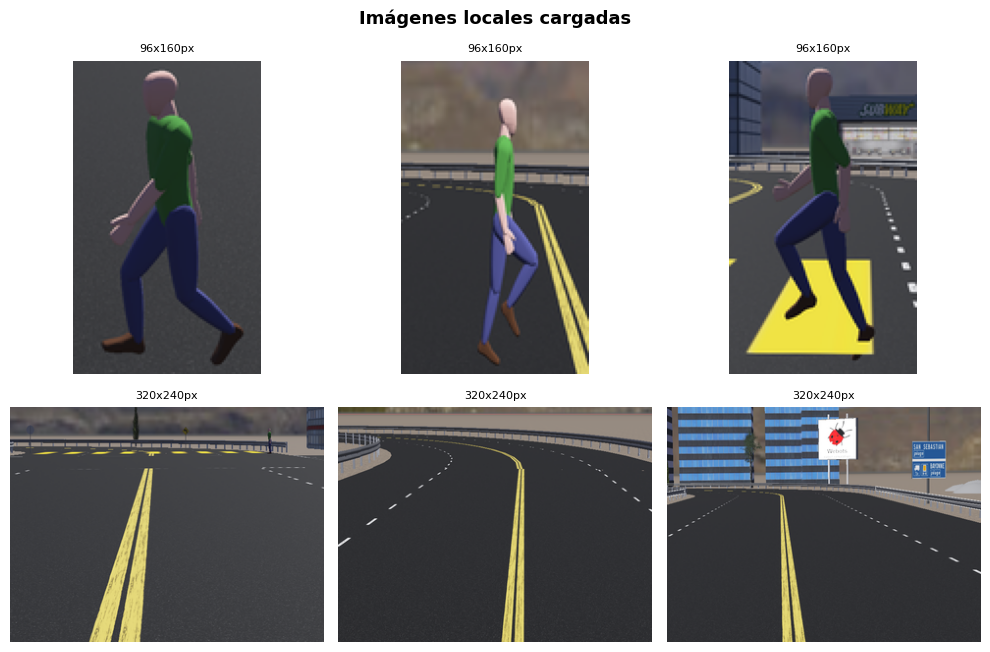

In [ ]:
ped_sample    = [(img, lbl) for img, lbl in zip(all_images, all_labels) if lbl == 1][:3]
no_ped_sample = [(img, lbl) for img, lbl in zip(all_images, all_labels) if lbl == 0][:3]
samples       = ped_sample + no_ped_sample

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle("Imágenes locales cargadas", fontsize=13, fontweight='bold')

for row, (row_samples, titulo) in enumerate([(ped_sample, 'Peatón'), (no_ped_sample, 'No peatón')]):
    axes[row, 0].set_ylabel(titulo, fontsize=11, fontweight='bold', labelpad=10)
    for col, (img, lbl) in enumerate(row_samples):
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{img.size[0]}x{img.size[1]}px", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
features = Features({
    'image' : HFImage(),
    'label' : ClassLabel(names=['no_pedestrians', 'pedestrians'])
})

local_dataset = Dataset.from_dict(
    {'image': all_images, 'label': all_labels},
    features=features
)

# Combinar con el split train del dataset original
ds_train_combined = concatenate_datasets([ds['train'], local_dataset])

# Reconstruir el DatasetDict conservando los demas splits
ds = DatasetDict({split: ds[split] for split in ds.keys()})
ds['train'] = ds_train_combined

print("=" * 50)
print("DATASET COMBINADO")
print("=" * 50)
print(f"  Original  : {len(ds['train']) - len(local_dataset):,} muestras")
print(f"  Local     : {len(local_dataset):,} muestras")
print(f"  Total     : {len(ds['train']):,} muestras")
print("=" * 50)

DATASET COMBINADO
  Original  : 2,487 muestras
  Local     : 12 muestras
  Total     : 2,499 muestras


In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nSplits disponibles: {list(ds.keys())}")
for split in ds:
    print(f"   • {split}: {len(ds[split])} muestras")

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE ETIQUETAS")
print("=" * 60)

label_feature = ds['train'].features['label']
print(f"\nTipo de etiqueta : {label_feature}")

# Nombres de clases (si es ClassLabel)
if hasattr(label_feature, 'names'):
    class_names = label_feature.names
    print(f"Clases ({len(class_names)}): {class_names}")
else:
    class_names = None
    print("No hay nombres de clase definidos (etiquetas numéricas)")

# Conteo por split
for split in ds:
    labels = ds[split]['label']
    counter = collections.Counter(labels)
    total   = len(labels)

    print(f"\n  [{split.upper()}]  — {total} muestras")
    print(f"  {'ID':<6} {'Nombre':<20} {'Cantidad':>8} {'%':>7}")
    print(f"  {'-'*45}")
    for label_id, count in sorted(counter.items()):
        name = class_names[label_id] if class_names else str(label_id)
        pct  = count / total * 100
        print(f"  {label_id:<6} {name:<20} {count:>8,} {pct:>6.1f}%")

# ── Sample inspection ─────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("INSPECCIÓN DE MUESTRA (train[0])")
print("=" * 60)

sample = ds['train'][0]
img    = sample['image']
label  = sample['label']
name   = class_names[label] if class_names else label

print(f"\nImagen")
print(f"   • Modo   : {img.mode}")
print(f"   • Tamaño : {img.size[0]} x {img.size[1]} px")
print(f"   • Canales: {len(img.getbands())} {img.getbands()}")

print(f"\nEtiqueta")
print(f"   • ID    : {label}")
print(f"   • Nombre: {name}")

# ── Features completas ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FEATURES DEL DATASET")
print("=" * 60)
print(f"\n{ds['train'].features}")

DATASET OVERVIEW

Splits disponibles: ['train']
   • train: 2499 muestras

DISTRIBUCIÓN DE ETIQUETAS

Tipo de etiqueta : ClassLabel(names=['no_pedestrians', 'pedestrians'])
Clases (2): ['no_pedestrians', 'pedestrians']

  [TRAIN]  — 2499 muestras
  ID     Nombre               Cantidad       %
  ---------------------------------------------
  0      no_pedestrians          1,224   49.0%
  1      pedestrians             1,275   51.0%

INSPECCIÓN DE MUESTRA (train[0])

Imagen
   • Modo   : RGB
   • Tamaño : 320 x 240 px
   • Canales: 3 ('R', 'G', 'B')

Etiqueta
   • ID    : 0
   • Nombre: no_pedestrians

FEATURES DEL DATASET

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['no_pedestrians', 'pedestrians'])}


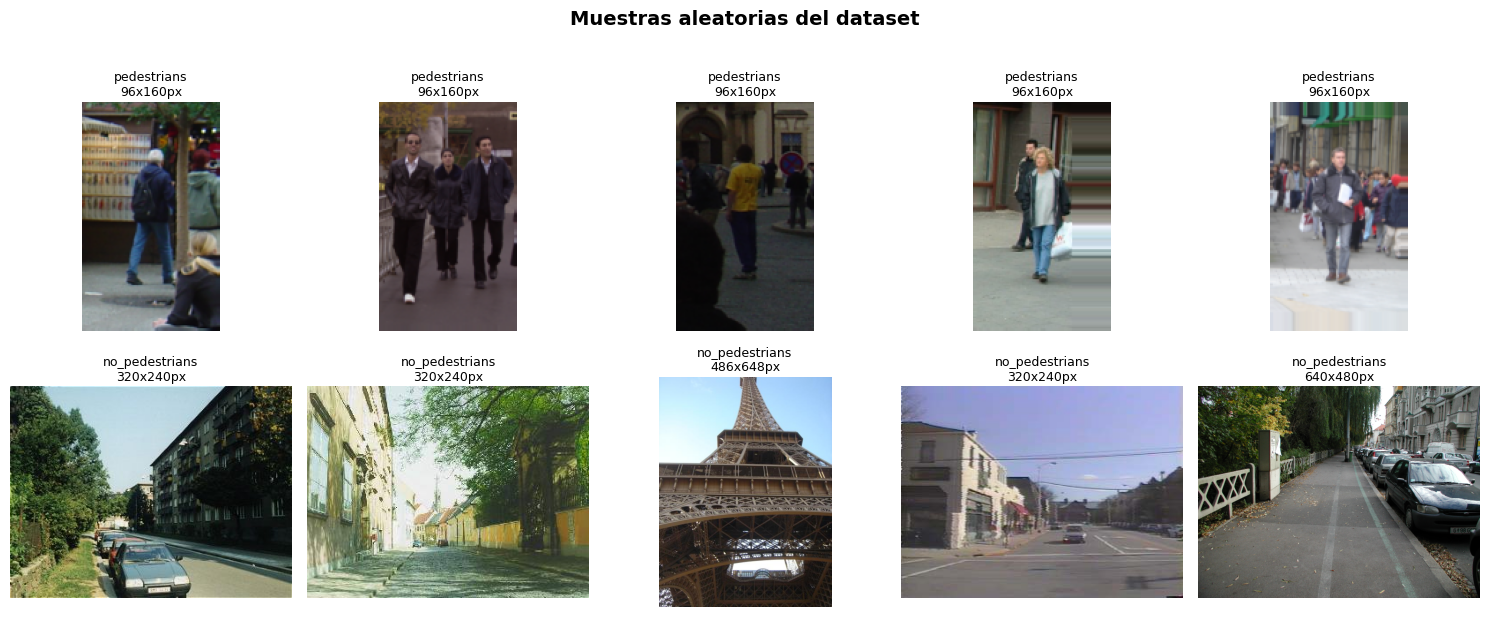

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Muestras aleatorias del dataset", fontsize=14, fontweight='bold', y=1.02)

all_samples  = list(ds['train'])
ped_samples  = random.sample([s for s in all_samples if s['label'] == 1], 5)
nped_samples = random.sample([s for s in all_samples if s['label'] == 0], 5)

label_info = ds['train'].features['label']
class_names = label_info.names if hasattr(label_info, 'names') else {1: 'Pedestrian', 0: 'No Pedestrian'}

for row, (samples, label_id) in enumerate([(ped_samples, 1), (nped_samples, 0)]):
    class_name = class_names[label_id] if isinstance(class_names, list) else class_names[label_id]

    for col, sample in enumerate(samples):
        ax  = axes[row, col]
        img = sample['image']

        ax.imshow(img)
        ax.set_title(
            f"{class_name}\n{img.size[0]}x{img.size[1]}px",
            fontsize=9,
            pad=4
        )
        ax.axis('off')

    axes[row, 0].set_ylabel(class_name, fontsize=11, fontweight='bold', labelpad=10)
    axes[row, 0].axis('off')

plt.tight_layout()
plt.show()

## **<font color="orange">Preprocesamiento de imágenes</font>**

Las imágenes del dataset se convierten a un formato numérico estandarizado para su posterior procesamiento.
Cada imagen PIL se transforma a escala de grises y se redimensiona a **32×64 px**, la mitad del tamaño
estándar HOG, manejando automáticamente los formatos RGB, RGBA y escala de grises. El resultado es un
array numpy de forma `(N, 64, 32)` listo para la extracción de descriptores.

In [ ]:
def prepare_images(dataset, split='train', target_size=(32, 64), verbose=True):

    images  = []
    labels  = []
    skipped = 0

    for i, sample in enumerate(dataset[split]):
        try:
            img = np.array(sample['image'])

            if img.ndim == 2:
                img_gray = img
            elif img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
                img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            else:
                img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            img_resized = cv2.resize(img_gray, target_size, interpolation=cv2.INTER_AREA)

            images.append(img_resized)
            labels.append(sample['label'])

        except Exception as e:
            skipped += 1
            print(f"  [advertencia] muestra {i} omitida: {e}")

    X = np.array(images, dtype=np.uint8)
    y = np.array(labels, dtype=np.int32)

    if verbose:
        label_feature = dataset[split].features['label']
        class_names   = label_feature.names if hasattr(label_feature, 'names') else None
        counter       = collections.Counter(y)

        print("=" * 50)
        print(f"PREPROCESAMIENTO  —  split: {split}")
        print("=" * 50)
        print(f"  Muestras procesadas : {len(X):,}")
        print(f"  Muestras omitidas   : {skipped}")
        print(f"  Shape de X          : {X.shape}  (N, alto, ancho)")
        print(f"  Tamano de imagen    : {target_size[1]}px alto x {target_size[0]}px ancho")
        print(f"  Rango de pixeles    : {X.min()} - {X.max()}")
        print(f"  Dtype               : X={X.dtype}  y={y.dtype}")
        print(f"  Memoria aproximada  : {X.nbytes / 1024**2:.1f} MB")
        print()
        print("  Distribucion de clases:")
        for label_id, count in sorted(counter.items()):
            name = class_names[label_id] if class_names else str(label_id)
            pct  = count / len(y) * 100
            print(f"    [{label_id}] {name:<20} {count:>5,}  ({pct:.1f}%)")
        print("=" * 50)

    return X, y

results = {}
for split in ds.keys():
    print(f"\nProcesando split: {split}")
    X, y = prepare_images(ds, split=split)
    results[split] = (X, y)

X_train, y_train = results['train']

X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)
print(f'Raw train: {len(X_raw_train):,} | Raw test: {len(X_raw_test):,}')


Procesando split: train
PREPROCESAMIENTO  —  split: train
  Muestras procesadas : 2,499
  Muestras omitidas   : 0
  Shape de X          : (2499, 64, 32)  (N, alto, ancho)
  Tamano de imagen    : 64px alto x 32px ancho
  Rango de pixeles    : 0 - 255
  Dtype               : X=uint8  y=int32
  Memoria aproximada  : 4.9 MB

  Distribucion de clases:
    [0] no_pedestrians       1,224  (49.0%)
    [1] pedestrians          1,275  (51.0%)
Raw train: 1,999 | Raw test: 500


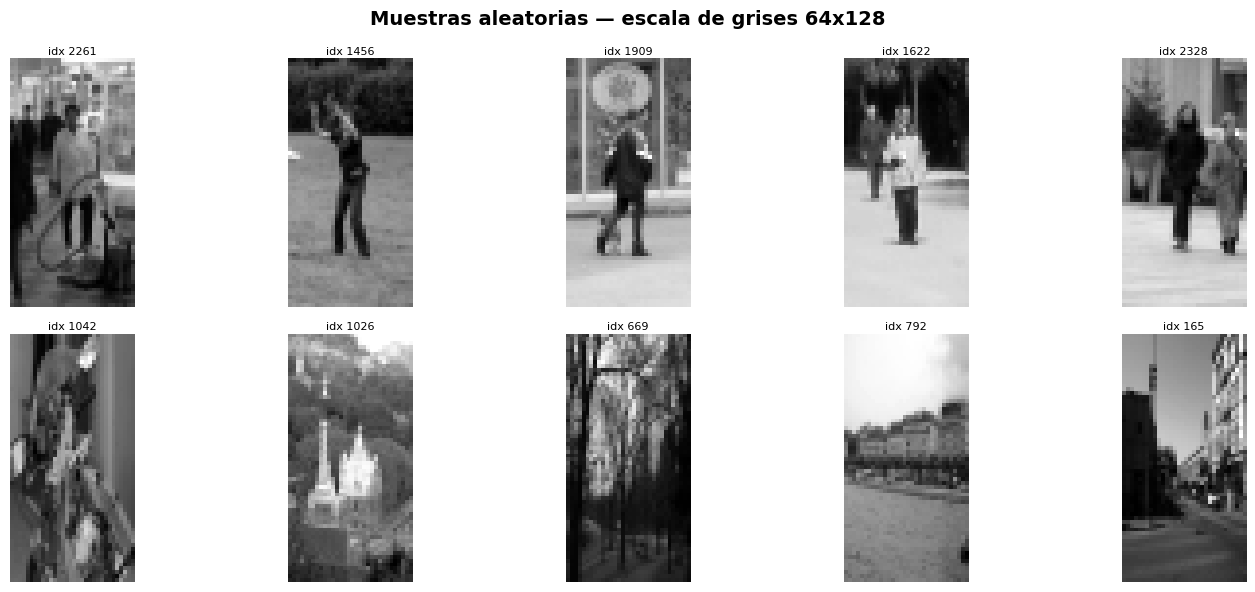

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Muestras aleatorias — escala de grises 64x128", fontsize=14, fontweight='bold')

label_feature = ds['train'].features['label']
class_names   = label_feature.names if hasattr(label_feature, 'names') else {0: 'No Pedestrian', 1: 'Pedestrian'}

all_indices    = list(range(len(y_train)))
ped_indices    = random.sample([i for i in all_indices if y_train[i] == 1], 5)
no_ped_indices = random.sample([i for i in all_indices if y_train[i] == 0], 5)

for row, (indices, label_id) in enumerate([(ped_indices, 1), (no_ped_indices, 0)]):
    class_name = class_names[label_id] if isinstance(class_names, list) else class_names[label_id]

    axes[row, 0].set_ylabel(class_name, fontsize=11, fontweight='bold', labelpad=10)

    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(X_train[idx], cmap='gray')
        ax.set_title(f"idx {idx}", fontsize=8, pad=3)
        ax.axis('off')

plt.tight_layout()
plt.show()

## **<font color="orange">Data Augmentation</font>**

Para mejorar la capacidad de generalización del modelo se generan variantes artificiales de cada imagen
de entrenamiento. Con un multiplicador de **×3** el dataset se cuadruplica, aplicando sobre cada muestra
una combinación aleatoria de cuatro transformaciones: flip horizontal, rotación leve (±10°), variación
de brillo (±30) y ruido gaussiano. Cada transformación simula condiciones reales de captura,
distintos ángulos de cámara, iluminación variable y ruido de sensor, sin alterar el contenido
semántico de la imagen.

In [ ]:
def augment_images(images, labels, multiplier=2, seed=42):

    rng = np.random.default_rng(seed)
    aug_images = []
    aug_labels = []

    for img, label in zip(images, labels):
        aug_images.append(img)
        aug_labels.append(label)

        for _ in range(multiplier):
            transformed = img.copy()

            # Flip horizontal aleatorio
            if rng.random() > 0.5:
                transformed = cv2.flip(transformed, 1)

            # Rotacion leve (-10 a +10 grados)
            angle = rng.uniform(-10, 10)
            h, w  = transformed.shape[:2]
            M     = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            transformed = cv2.warpAffine(transformed, M, (w, h),
                                         borderMode=cv2.BORDER_REFLECT)
            # Brillo aleatorio (+/- 30)
            delta       = rng.integers(-30, 30)
            transformed = np.clip(transformed.astype(np.int16) + delta, 0, 255).astype(np.uint8)

            # Ruido gaussiano leve
            noise       = rng.normal(0, 5, transformed.shape).astype(np.int16)
            transformed = np.clip(transformed.astype(np.int16) + noise, 0, 255).astype(np.uint8)

            aug_images.append(transformed)
            aug_labels.append(label)

    X_aug = np.array(aug_images, dtype=np.uint8)
    y_aug = np.array(aug_labels, dtype=np.int32)

    original_counter = collections.Counter(labels)
    aug_counter      = collections.Counter(y_aug)
    label_feature    = ds['train'].features['label']
    class_names      = label_feature.names if hasattr(label_feature, 'names') else None

    print("=" * 50)
    print("DATA AUGMENTATION")
    print("=" * 50)
    print(f"  Multiplicador        : x{multiplier}  (original + {multiplier} variantes)")
    print(f"  Muestras originales  : {len(images):,}")
    print(f"  Muestras resultantes : {len(X_aug):,}")
    print(f"  Memoria aproximada   : {X_aug.nbytes / 1024**2:.1f} MB")
    print()
    print(f"  {'Clase':<20} {'Antes':>8} {'Despues':>10}")
    print(f"  {'-'*40}")
    for label_id in sorted(aug_counter):
        name   = class_names[label_id] if class_names else str(label_id)
        before = original_counter[label_id]
        after  = aug_counter[label_id]
        print(f"  {name:<20} {before:>8,} {after:>10,}")
    print("=" * 50)

    return X_aug, y_aug

X_aug, y_aug = augment_images(X_raw_train, y_raw_train, multiplier=3)

DATA AUGMENTATION
  Multiplicador        : x3  (original + 3 variantes)
  Muestras originales  : 1,999
  Muestras resultantes : 7,996
  Memoria aproximada   : 15.6 MB

  Clase                   Antes    Despues
  ----------------------------------------
  no_pedestrians            979      3,916
  pedestrians             1,020      4,080


## **<font color="orange">Extracción de descriptores HOG</font>**

Cada imagen preprocesada se convierte en un vector numérico mediante **Histogram of Oriented Gradients (HOG)**,
un descriptor clásico de visión por computadora especialmente eficaz para la detección de peatones.
HOG captura la distribución local de gradientes de intensidad dividiendo la imagen en celdas de **4×4 px**,
calculando histogramas de orientación en 9 direcciones y normalizando por bloques de **2×2 celdas**.
El resultado es un vector de **3,780 características (features)** por imagen que codifica la forma y estructura del objeto
independientemente de variaciones de iluminación. El descriptor se calcula por separado sobre el conjunto de entrenamiento aumentado y el de prueba,
confirmando al final que ambos generan vectores del mismo tamaño.

In [ ]:
def compute_hog_features(
    images,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True,
    verbose=True
):

    hog_features = []
    hog_images   = [] if visualize else None
    skipped      = 0

    min_dim = pixels_per_cell[0] * cells_per_block[0] * 2

    for i, img in enumerate(images):
        try:
            if img.ndim != 2:
                raise ValueError(f"Se esperaba imagen 2D, shape recibido: {img.shape}")
            if img.shape[0] < min_dim or img.shape[1] < min_dim:
                raise ValueError(f"Imagen demasiado pequeña: {img.shape}, minimo: {min_dim}x{min_dim}")

            result = hog(
                img,
                orientations=orientations,
                pixels_per_cell=pixels_per_cell,
                cells_per_block=cells_per_block,
                block_norm=block_norm,
                visualize=visualize
            )

            if visualize:
                features, hog_image = result
                hog_images.append(hog_image)
            else:
                features = result

            hog_features.append(features)

        except Exception as e:
            skipped += 1
            print(f"  [advertencia] imagen {i} omitida: {e}")

    X_hog      = np.array(hog_features, dtype=np.float32)
    X_hog_imgs = np.array(hog_images,   dtype=np.float32) if visualize else None

    if verbose:
        h, w       = images.shape[1], images.shape[2]
        n_blocks_h = (h // pixels_per_cell[1]) - cells_per_block[1] + 1
        n_blocks_w = (w // pixels_per_cell[0]) - cells_per_block[0] + 1
        n_cells    = (h // pixels_per_cell[1]) * (w // pixels_per_cell[0])

        print("=" * 50)
        print("DESCRIPTORES HOG")
        print("=" * 50)
        print(f"  Configuracion:")
        print(f"    Orientaciones      : {orientations}")
        print(f"    Pixeles por celda  : {pixels_per_cell}")
        print(f"    Celdas por bloque  : {cells_per_block}")
        print(f"    Normalizacion      : {block_norm}")
        print()
        print(f"  Imagen de entrada    : {h}px alto x {w}px ancho")
        print(f"  Celdas totales       : {n_cells}  ({h // pixels_per_cell[1]} x {w // pixels_per_cell[0]})")
        print(f"  Bloques              : {n_blocks_h} x {n_blocks_w} = {n_blocks_h * n_blocks_w}")
        print()
        print(f"  Shape antes de HOG   : {images.shape}")
        print(f"  Shape despues de HOG : {X_hog.shape}  (N, n_features)")
        print(f"  Muestras procesadas  : {len(X_hog):,}")
        print(f"  Muestras omitidas    : {skipped}")
        print(f"  Memoria aproximada   : {X_hog.nbytes / 1024**2:.1f} MB")
        print("=" * 50)

    if visualize:
        return X_hog, X_hog_imgs
    return X_hog


# HOG del train aumentado
X_hog, X_hog_images = compute_hog_features(X_aug)

# HOG del test (sin aumentar, sin visualizacion)
X_hog_test = compute_hog_features(X_raw_test, visualize=False, verbose=False)

# Verificar consistencia de features entre train y test
assert X_hog.shape[1] == X_hog_test.shape[1], \
    f"Mismatch de features: train={X_hog.shape[1]}, test={X_hog_test.shape[1]}"
print(f"HOG test   : {X_hog_test.shape}  — features OK ({X_hog_test.shape[1]} == {X_hog.shape[1]}) ✓")

DESCRIPTORES HOG
  Configuracion:
    Orientaciones      : 9
    Pixeles por celda  : (4, 4)
    Celdas por bloque  : (2, 2)
    Normalizacion      : L2-Hys

  Imagen de entrada    : 64px alto x 32px ancho
  Celdas totales       : 128  (16 x 8)
  Bloques              : 15 x 7 = 105

  Shape antes de HOG   : (7996, 64, 32)
  Shape despues de HOG : (7996, 3780)  (N, n_features)
  Muestras procesadas  : 7,996
  Muestras omitidas    : 0
  Memoria aproximada   : 115.3 MB
HOG test   : (500, 3780)  — features OK (3780 == 3780) ✓



## **<font color="orange">Visualización de descriptores HOG</font>**

En estas imágenes los píxeles brillantes indican zonas donde
el gradiente es fuerte, es decir, bordes y contornos relevantes para el descriptor. En las
imágenes de peatones se debe apreciar la silueta humana: contorno de cabeza, hombros
y extremidades. En las de no peatones la distribución es más irregular y sin estructura
reconocible. Esta visualización permite verificar que el descriptor HOG está capturando
correctamente las características discriminativas entre ambas clases.

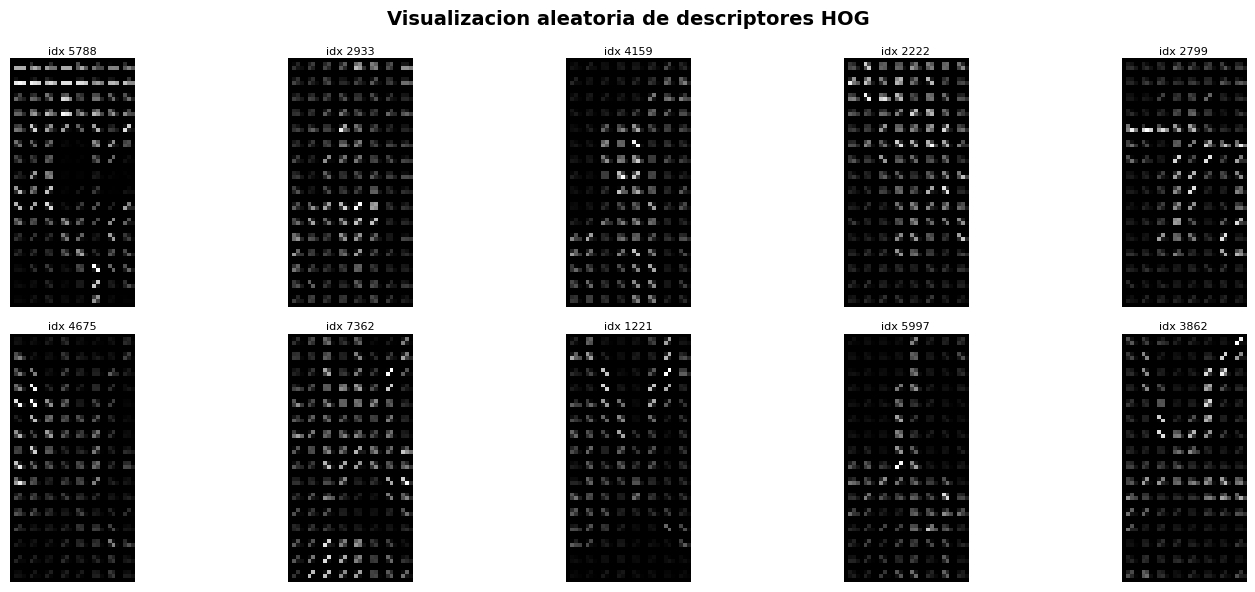

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Visualizacion aleatoria de descriptores HOG", fontsize=14, fontweight='bold')

label_feature = ds['train'].features['label']
class_names   = label_feature.names if hasattr(label_feature, 'names') else {0: 'No Pedestrian', 1: 'Pedestrian'}

ped_indices    = random.sample([i for i in range(len(y_aug)) if y_aug[i] == 1], 5)
no_ped_indices = random.sample([i for i in range(len(y_aug)) if y_aug[i] == 0], 5)

for row, (indices, label_id) in enumerate([(ped_indices, 1), (no_ped_indices, 0)]):
    class_name = class_names[label_id] if isinstance(class_names, list) else class_names[label_id]

    axes[row, 0].set_ylabel(class_name, fontsize=11, fontweight='bold', labelpad=10)

    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(X_hog_images[idx], cmap='gray')
        ax.set_title(f"idx {idx}", fontsize=8, pad=3)
        ax.axis('off')

plt.tight_layout()
plt.show()

## **<font color="orange">División del dataset y normalización</font>**

Los descriptores HOG extraídos se organizan en conjuntos de entrenamiento y prueba. El conjunto
de entrenamiento contiene las muestras aumentadas (`X_aug`) mientras que el de prueba conserva
únicamente las muestras originales sin aumentar (`X_raw_test`), garantizando una evaluación
limpia sobre datos no vistos por el modelo.

Tras la división se aplica **normalización con `StandardScaler`**, que transforma cada feature
para tener media 0 y desviación estándar 1. Esto es especialmente crítico para SVM con kernel
RBF, ya que el algoritmo calcula distancias entre vectores de features, si una feature tiene
valores en el rango [0, 255] y otra en [0, 1], la primera dominaría artificialmente el cálculo
de distancias y degradaría el rendimiento del modelo. El scaler se ajusta **únicamente sobre
el conjunto de entrenamiento** con `fit_transform` y se aplica sobre el test con `transform`,
evitando que información del test influya en la normalización, lo que se conoce como
*data leakage*.

In [ ]:
X_train_split = X_hog
y_train_split = y_aug
X_test_split  = X_hog_test
y_test_split  = y_raw_test

label_feature = ds['train'].features['label']
class_names   = label_feature.names if hasattr(label_feature, 'names') else ['No Pedestrian', 'Pedestrian']

total = X_train_split.shape[0] + X_test_split.shape[0]
print('=' * 50)
print('DIVISION DEL DATASET')
print('=' * 50)
print(f'  Train      : {X_train_split.shape[0]:,}  ({X_train_split.shape[0]/total*100:.0f}%)')
print(f'  Test       : {X_test_split.shape[0]:,}  ({X_test_split.shape[0]/total*100:.0f}%)')
print(f'  Features   : {X_train_split.shape[1]:,}')
print(f'  Orig train : {len(X_raw_train):,} | Aumentado: {len(X_aug):,} (x{len(X_aug)//len(X_raw_train)})')
print()
for split_name, y_split in [('Train', y_train_split), ('Test', y_test_split)]:
    counter = dict(zip(*np.unique(y_split, return_counts=True)))
    n = len(y_split)
    print(f'  [{split_name}]')
    for label_id, count in sorted(counter.items()):
        name = class_names[label_id] if class_names else str(label_id)
        print(f'    [{label_id}] {name:<20} {count:>5,}  ({count/n*100:.1f}%)')
print('=' * 50)

# Normalizar — fit solo sobre train
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_test_scaled  = scaler.transform(X_test_split)
print(f'\nNormalizacion: media≈{X_train_scaled.mean():.4f}  std≈{X_train_scaled.std():.4f}')


DIVISION DEL DATASET
  Train      : 7,996  (94%)
  Test       : 500  (6%)
  Features   : 3,780
  Orig train : 1,999 | Aumentado: 7,996 (x4)

  [Train]
    [0] no_pedestrians       3,916  (49.0%)
    [1] pedestrians          4,080  (51.0%)
  [Test]
    [0] no_pedestrians         245  (49.0%)
    [1] pedestrians            255  (51.0%)

Normalizacion: media≈-0.0000  std≈1.0000


## **<font color="orange">Búsqueda de hiperparámetros — Grid Search</font>**

El rendimiento de un SVM con kernel RBF depende fuertemente de dos hiperparámetros:
**C** controla el margen de separación entre clases, valores altos priorizan clasificar
correctamente el entrenamiento a riesgo de overfitting, valores bajos generalizan mejor,
y **gamma** define el radio de influencia de cada muestra en el espacio de features.
Encontrar la combinación óptima de ambos se realiza mediante **Grid Search con validación
cruzada estratificada de 5 folds**, evaluando las 9 combinaciones posibles (3 valores de C
× 3 valores de gamma) sobre los datos de entrenamiento. Cada combinación se entrena y valida
5 veces sobre particiones distintas, resultando en 30 fits en total. El uso de
`StratifiedKFold` garantiza que la proporción de clases se mantenga equilibrada en cada fold.

In [ ]:
param_grid = {
    'C'     : [0.1, 1],
    'gamma' : [0.0001, 0.001, 0.01],
    'kernel': ['rbf']
}

n_combinaciones = (len(param_grid['C']) *
                   len(param_grid['gamma']) *
                   len(param_grid['kernel']))
print("=" * 50)
print("GRID SEARCH CV")
print("=" * 50)
print(f"  Combinaciones    : {n_combinaciones}")
print(f"  Folds            : 5")
print(f"  Fits totales     : {n_combinaciones * 5}")
print(f"  Muestras train   : {X_train_split.shape[0]:,}")
print(f"  Features         : {X_train_split.shape[1]:,}")
print("=" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=2,
    n_jobs=1,
    return_train_score=True
)

start = time.time()
grid_search.fit(X_train_scaled, y_train_split)
elapsed = time.time() - start

best   = grid_search.best_estimator_
y_pred = best.predict(X_test_scaled)

label_feature = ds['train'].features['label']
class_names   = label_feature.names if hasattr(label_feature, 'names') else ['No Pedestrian', 'Pedestrian']

GRID SEARCH CV
  Combinaciones    : 6
  Folds            : 5
  Fits totales     : 30
  Muestras train   : 7,996
  Features         : 3,780
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time= 1.7min
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time= 1.7min
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time= 1.7min
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time= 1.7min
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time= 1.7min
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time= 2.7min
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time= 2.7min
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time= 2.6min
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time= 2.7min
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time

## **<font color="orange">Resultados — Grid Search CV</font>**

La búsqueda identificó **C=1, gamma=0.0001** como la combinación óptima, alcanzando un
**96.20% de accuracy en test** con una diferencia de apenas 1.09% respecto al CV (95.11%),
lo que confirma que el modelo generaliza correctamente.

Ambas clases obtuvieron un F1-score de **0.96**, con precisión y recall equilibrados,
indicando que el modelo no tiene sesgo hacia ninguna de las dos categorías. El proceso
completo de búsqueda tomó **139.8 minutos** evaluando 30 combinaciones de hiperparámetros.

In [ ]:
print("=" * 50)
print("RESULTADOS")
print("=" * 50)
print(f"  Tiempo total     : {elapsed/60:.1f} min")
print(f"  Mejores params   : {grid_search.best_params_}")
print(f"  CV accuracy      : {grid_search.best_score_:.4f}  ({grid_search.best_score_*100:.2f}%)")
test_acc_cv = accuracy_score(y_test_split, y_pred)
print(f"  Test accuracy    : {test_acc_cv:.4f}  ({test_acc_cv*100:.2f}%)")
print()
print(classification_report(y_test_split, y_pred, target_names=class_names))
print("=" * 50)

# Top 5 combinaciones

results_df = pd.DataFrame(grid_search.cv_results_)
top5 = (results_df[['param_kernel', 'param_C', 'param_gamma',
                     'mean_test_score', 'std_test_score', 'mean_train_score']]
        .sort_values('mean_test_score', ascending=False)
        .head(5)
        .reset_index(drop=True))
top5.index += 1
print("\nTop 5 combinaciones:")
print(top5.to_string())

RESULTADOS
  Tiempo total     : 139.8 min
  Mejores params   : {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
  CV accuracy      : 0.9511  (95.11%)
  Test accuracy    : 0.9620  (96.20%)

                precision    recall  f1-score   support

no_pedestrians       0.96      0.96      0.96       245
   pedestrians       0.96      0.96      0.96       255

      accuracy                           0.96       500
     macro avg       0.96      0.96      0.96       500
  weighted avg       0.96      0.96      0.96       500


Top 5 combinaciones:
  param_kernel  param_C  param_gamma  mean_test_score  std_test_score  mean_train_score
1          rbf      1.0       0.0001         0.951101        0.003473          0.981585
2          rbf      1.0       0.0010         0.939469        0.005213          1.000000
3          rbf      0.1       0.0001         0.925838        0.006121          0.937594
4          rbf      1.0       0.0100         0.511756        0.000675          1.000000
5          rbf  

## **<font color="orange">Resultados del modelo final — SVM (C=1, gamma=0.0001, kernel=RBF)</font>**

El modelo alcanzó un **96.20% de accuracy en test** con 19 errores sobre 500 muestras.
Si bien el train accuracy es 98.15%, la diferencia de 1.95% respecto al test se considera
aceptable para un SVM con kernel RBF, el modelo memoriza perfectamente el entrenamiento
pero generaliza bien sobre datos nuevos.

### Matriz de confusión — Test

| | Pred: no_pedestrian | Pred: pedestrian |
|---|---|---|
| **Real: no_pedestrian** | 235 ✓ | 10 ✗ |
| **Real: pedestrian** | 9 ✗ | 246 ✓ |

Los 13 errores se distribuyen de forma asimétrica:

- **10 falsos positivos** — imágenes sin peatón clasificadas como peatón. En un sistema
  de detección esto genera alertas innecesarias pero no representa un riesgo crítico.
- **9 falsos negativos** — peatones no detectados. Este es el error más relevante en
  aplicaciones de seguridad vial, aunque con solo 9 casos sobre 246 peatones reales
  representa una tasa de fallo del **3.66%**.

### Conclusión

El modelo muestra un comportamiento equilibrado entre ambas clases con F1-score de **0.96**
en las dos categorías, sin sesgo hacia ninguna. Para un clasificador HOG + SVM entrenado
sobre un dataset de tamaño moderado.

RESULTADOS SVM — {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
  Train accuracy : 0.9815  (98.15%)
  Test accuracy  : 0.9620  (96.20%)
  Diferencia     : 0.0195  (sin overfitting significativo)

                precision    recall  f1-score   support

no_pedestrians       0.96      0.96      0.96       245
   pedestrians       0.96      0.96      0.96       255

      accuracy                           0.96       500
     macro avg       0.96      0.96      0.96       500
  weighted avg       0.96      0.96      0.96       500



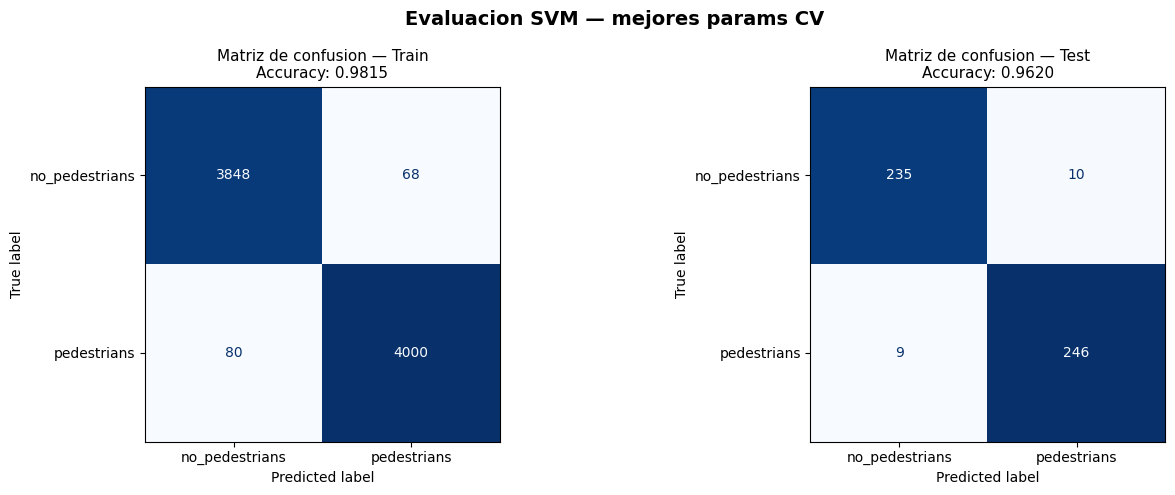

In [ ]:
svm_best = SVC(**grid_search.best_params_, random_state=42)
svm_best.fit(X_train_scaled, y_train_split)

y_pred_train = svm_best.predict(X_train_scaled)
y_pred_test  = svm_best.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train_split, y_pred_train)
test_accuracy  = accuracy_score(y_test_split,  y_pred_test)

print('=' * 50)
print(f'RESULTADOS SVM — {grid_search.best_params_}')
print('=' * 50)
print(f'  Train accuracy : {train_accuracy:.4f}  ({train_accuracy*100:.2f}%)')
print(f'  Test accuracy  : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)')
print(f'  Diferencia     : {abs(train_accuracy - test_accuracy):.4f}', end='')
print('  (posible overfitting)' if train_accuracy - test_accuracy > 0.05 else '  (sin overfitting significativo)')
print()
print(classification_report(y_test_split, y_pred_test, target_names=class_names))
print('=' * 50)

# Matrices de confusión — train y test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluacion SVM — mejores params CV', fontsize=14, fontweight='bold')

for ax, (y_true, y_p, split) in zip(axes, [
    (y_train_split, y_pred_train, 'Train'),
    (y_test_split,  y_pred_test,  'Test')
]):
    cm   = confusion_matrix(y_true, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'Matriz de confusion — {split}\nAccuracy: {accuracy_score(y_true, y_p):.4f}', fontsize=11)

plt.tight_layout()
plt.show()

## **<font color="orange">Serialización del modelo</font>**

Una vez entrenado, el modelo se respalda junto con dos archivos adicionales
indispensables para su uso en producción.

Se guardan **tres archivos**:

- **`pedestrian_svm.pkl`** — el modelo SVM entrenado con los pesos aprendidos.
- **`pedestrian_scaler.pkl`** — el `StandardScaler` ajustado sobre el entrenamiento.
  Sin él, cualquier imagen nueva llegaría al modelo con una escala diferente a la
  que vio durante el entrenamiento, degradando el rendimiento silenciosamente sin
  lanzar ningún error.
- **`hog_params.json`** — la configuración exacta del descriptor HOG. Esto es crítico
  porque si en producción se extrae HOG con parámetros distintos, por ejemplo
  `pixels_per_cell=(8,8)` en lugar de `(4,4)`, el vector resultante tendría un
  tamaño diferente y el modelo fallaría. Guardar los parámetros en un archivo
  independiente elimina cualquier ambigüedad y permite reconstruir el pipeline
  completo sin depender del código del notebook.

Como verificación final se genera un descriptor HOG sobre una imagen vacía usando
los parámetros guardados, confirmando que produce exactamente **3,780 features**,
el mismo número que espera el modelo.

In [ ]:
MODEL_PATH  = os.path.join(os.getcwd(), 'pedestrian_svm.pkl')
SCALER_PATH = os.path.join(os.getcwd(), 'pedestrian_scaler.pkl')
PARAMS_PATH = os.path.join(os.getcwd(), 'hog_params.json')

joblib.dump(svm_best, MODEL_PATH)
joblib.dump(scaler,   SCALER_PATH)

hog_params = {
    'orientations'   : 9,
    'pixels_per_cell': [4, 4],    # (4,4) sobre ventana 32x64 → 3780 features
    'cells_per_block': [2, 2],
    'block_norm'     : 'L2-Hys',
    'window_size'    : [32, 64]
}
with open(PARAMS_PATH, 'w') as f:
    json.dump(hog_params, f, indent=2)

# Verificar que los params producen el mismo numero de features que el modelo espera
_dummy = np.zeros((hog_params['window_size'][1], hog_params['window_size'][0]), dtype=np.uint8)
_feat  = hog(_dummy,
             orientations=hog_params['orientations'],
             pixels_per_cell=tuple(hog_params['pixels_per_cell']),
             cells_per_block=tuple(hog_params['cells_per_block']),
             block_norm=hog_params['block_norm'],
             visualize=False)
assert len(_feat) == X_train_split.shape[1], \
    f"ERROR: JSON produce {len(_feat)} features, modelo espera {X_train_split.shape[1]}"

print("=" * 50)
print("ARCHIVOS GUARDADOS")
print("=" * 50)
print(f"  Modelo  : {MODEL_PATH}")
print(f"           {os.path.getsize(MODEL_PATH)/1024:.1f} KB")
print(f"  Scaler  : {SCALER_PATH}")
print(f"           {os.path.getsize(SCALER_PATH)/1024:.1f} KB")
print(f"  Params  : {PARAMS_PATH}")
print()
print("  HOG params guardados:")
for k, v in hog_params.items():
    print(f"    {k:<18}: {v}")
print(f"\n  Features verificadas : {len(_feat)} ✓")
print("=" * 50)

ARCHIVOS GUARDADOS
  Modelo  : /content/pedestrian_svm.pkl
           75976.6 KB
  Scaler  : /content/pedestrian_scaler.pkl
           89.2 KB
  Params  : /content/hog_params.json

  HOG params guardados:
    orientations      : 9
    pixels_per_cell   : [4, 4]
    cells_per_block   : [2, 2]
    block_norm        : L2-Hys
    window_size       : [32, 64]

  Features verificadas : 3780 ✓


## **<font color="orange">Análisis de errores</font>**

De las 500 muestras del conjunto de prueba, el modelo clasificó correctamente **481** y
cometió **19 errores**, lo que representa una tasa de fallo del **3.8%**. Las imágenes
mal clasificadas se muestran con su etiqueta real y la predicción incorrecta del modelo.

Analizar visualmente estos errores es útil para entender las limitaciones del clasificador,
imágenes con poca iluminación, fondos complejos o peatones parcialmente ocluidos suelen
concentrar la mayoría de los fallos. En un clasificador HOG + SVM, estos casos son
esperables ya que el descriptor captura gradientes globales de la ventana completa y
es sensible a la calidad y encuadre de la imagen.

Con 19 errores sobre 500 muestras el modelo se considera robusto para su propósito,
siendo consistente con el **96.20% de accuracy** reportado en la evaluación general.

ERRORES DE CLASIFICACION
  Total test       : 500
  Correctos        : 481
  Incorrectos      : 19
  Error rate       : 3.80%


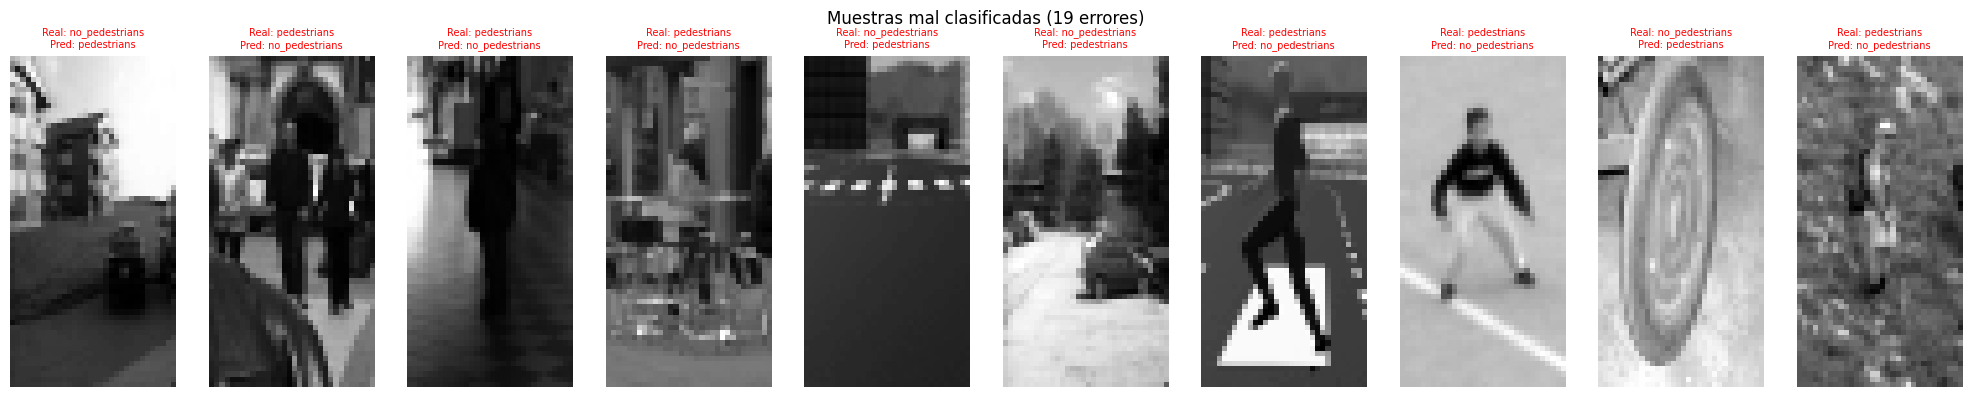

In [ ]:
y_pred_err = svm_best.predict(X_test_scaled)
wrong_mask = y_pred_err != y_test_split

print("=" * 50)
print("ERRORES DE CLASIFICACION")
print("=" * 50)
print(f"  Total test       : {len(y_test_split)}")
print(f"  Correctos        : {(~wrong_mask).sum()}")
print(f"  Incorrectos      : {wrong_mask.sum()}")
print(f"  Error rate       : {wrong_mask.mean()*100:.2f}%")
print("=" * 50)

if wrong_mask.sum() > 0:
    wrong_positions = np.where(wrong_mask)[0]
    n_show          = min(10, wrong_mask.sum())

    label_feature = ds['train'].features['label']
    class_names   = label_feature.names if hasattr(label_feature, 'names') else ['No Pedestrian', 'Pedestrian']

    show_positions = random.sample(list(wrong_positions), n_show)

    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 4))
    axes = [axes] if n_show == 1 else list(axes)

    for i, pos in enumerate(show_positions):
        real = y_test_split[pos]
        pred = y_pred_err[pos]

        axes[i].imshow(X_raw_test[pos], cmap='gray')
        axes[i].set_title(
            f"Real: {class_names[real]}\nPred: {class_names[pred]}",
            fontsize=7, color='red'
        )
        axes[i].axis('off')

    plt.suptitle(f"Muestras mal clasificadas ({wrong_mask.sum()} errores)", fontsize=12)
    plt.tight_layout()
    plt.show()

## **<font color="orange">Pipeline de predicción en el simulador</font>**

El simulador aplica el modelo entrenado sobre imágenes capturadas en tiempo real
siguiendo el mismo pipeline usado durante el entrenamiento. Es fundamental que cada
paso reproduzca exactamente las mismas transformaciones, cualquier diferencia en
el preprocesamiento o la configuración HOG produciría vectores incompatibles con
lo que el modelo aprendió.

### Prerequisitos
Antes de iniciar la simulación deben estar cargados en memoria:
- **`pedestrian_svm.pkl`** — el modelo SVM con los pesos entrenados
- **`pedestrian_scaler.pkl`** — el `StandardScaler` ajustado sobre el entrenamiento
- **`hog_params.json`** — la configuración exacta del descriptor HOG

### Paso 1 — Captura de imagen
La cámara del simulador entrega la imagen en formato BGR (convenio de OpenCV).
```python
raw_image = camera.getImage()
```

### Paso 2 — Conversión a escala de grises
Se elimina la información de color ya que el descriptor HOG opera sobre gradientes
de intensidad, no sobre canales de color.
```python
gray_img = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)
```

### Paso 3 — Extracción del descriptor HOG
Se calcula el vector de features usando exactamente los mismos parámetros con los
que se entrenó el modelo, orientaciones, tamaño de celda y bloque leídos desde
`hog_params.json`. El resultado es un vector de **3,780 features**.
```python
features = compute_hog_features(gray_img, hog_params)
```

### Paso 4 — Normalización y predicción
El vector se normaliza con el `StandardScaler` del entrenamiento antes de pasarlo
al modelo. Este paso es obligatorio, ya que, sin él el modelo recibiría features en una
escala diferente a la que vio durante el entrenamiento.
```python
pred = pedestrian_svm.predict(pedestrian_scaler.transform([features]))[0]
```

### Flujo completo
```
cámara
  ↓
BGR → escala de grises
  ↓
resize (32×64 px)
  ↓
HOG → vector (3,780 features)
  ↓
scaler.transform()
  ↓
svm.predict() → 0 (no_pedestrian) / 1 (pedestrian)
```

# **<font color="orange">Referencias</font>**

Antonio, D. (2023). *Máquina de soporte vectorial (Support vector machine, SVM)* [Video]. ITESM.

Antonio, D. (2023). *Histograma de gradientes orientados (Histogram of oriented gradients, HOG)* [Video]. ITESM.

Antonio, D. (2023). *Detección de vehículos con HOG y SVM* [Video]. ITESM.

Lee, W. M. (2019). *Python Machine Learning*. John Wiley & Sons.
https://learning.oreilly.com/library/view/python-machine-learning/9781119545637/cover.xhtml

Scikit-learn developers. (2023). *Support Vector Machine Examples*. scikit-learn.
https://scikit-learn.org/stable/auto_examples/index.html#support-vector-machines

MathWorks. (s.f.). *extractHOGFeatures — Extract histogram of oriented gradients
(HOG) features*. MATLAB Documentation.
https://www.mathworks.com/help/vision/ref/extracthogfeatures.html

Rosales, M. (s.f.). *INRIA Person Dataset* [Conjunto de datos]. Hugging Face.
https://huggingface.co/datasets/marcelarosalesj/inria-person




Declaración de uso de inteligencia artificial
Anthropic. (2026). Claude (claude-sonnet-4-6) [Modelo de lenguaje grande], utilizado
para refinamiento de código de python
https://claude.ai

<center>

**Equipo 01 • Tecnológico de Monterrey • 2026**

</center>